# ¿Cuál es la mejor tarifa?

Trabaje como analista para un operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Realice un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tenía los datos de 500 clientes: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Mi trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

***Objetivos del análisis*** 

En primera instancia se prepararan los datos  de las diferentes fuentes proporcionadas,(users, calls, messages, internet, plans), revisando datos faltantes, nombres de columnas y el tipo de dato usado para casa columna.

Se pretende ver el comportamiento de los usuarios según el plan contratado, así comoo el análisis de ingresos de cada uno de éstos.

Se haran algunas gráficas para la visualización de datos 


## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd  # Para manipulación de datos
import numpy as np  # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para visualización de datos
import seaborn as sns  # Para gráficos estadísticos
from scipy import stats  # Para pruebas estadísticas

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')

## Preparar los datos

Se procedera a explorar cada tabla para tener una comprensión inicial de los datos y si es necesario, hacer las correcciones requeridas en cada tabla para el uso de la información, como tipo de dato en cada columna, veirficar duplicados o valores nulos.

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(plans.info())

display(plans.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000
mean,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
std,671.751442,10861.160159,1767.766953,35.355339,2.12132,0.014142,0.014142
min,50.000000,15360.000000,500.000000,20.000000,7.00000,0.010000,0.010000
25%,287.500000,19200.000000,1125.000000,32.500000,7.75000,0.015000,0.015000
50%,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000
75%,762.500000,26880.000000,2375.000000,57.500000,9.25000,0.025000,0.025000
max,1000.000000,30720.000000,3000.000000,70.000000,10.00000,0.030000,0.030000


In [4]:
# Imprime una muestra de los datos para las tarifas
display (plans.head())

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


***Al imprimir la información general sobre las tarifas (plans), se observa que:***

Todos los valores parecen tener el tipo de datos adecuado en cada columna, y no hay valores faltantes o valores nulos.
Se observa la descripción de lo que ofrece cada plan.

## Corregir datos

***Nombre de columnas***: Se modificar los nombres de las columnas "usd_per_gb", "usd_per_message" y "usd_per_minute" a 'usd_per_extra_gb', 'usd_per_extra_sms' y 'usd_per_extra_min.

Ya que representa el costo "Extra" si se exede el límite del paquete en dólares por persona por: cada gigabyte (GB) de datos utilizado, cada mensaje (SMS) enviado y cada minuto de llamada.

Se modifica de la columna "usd_monthly_pay" a "usd_monthly_fee", para que coincida con la descripción de los datos en el diccionario de datos.

In [5]:
plans= plans.rename(columns={
    'usd_monthly_pay': 'usd_monthly_fee',
    'usd_per_gb': 'usd_per_extra_gb',
    'usd_per_message': 'usd_per_extra_sms',
    'usd_per_minute': 'usd_per_extra_min'})

display(plans.head())

,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_extra_gb,usd_per_extra_sms,usd_per_extra_min,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Enriquecer los datos

Considero que podria enriquecer los datos al incluir el costo real por minuto, SMS y GB en cada plan, si el usuario no exediera el limite de su plan, para ayudarnos a entender cual seria el plan económico.

In [6]:
# Agregar columnas con el costo por unidad dentro del paquete
plans['usd_per_min_included'] = plans['usd_monthly_fee'] / plans['minutes_included']
plans['usd_per_sms_included'] = plans['usd_monthly_fee'] / plans['messages_included'].replace(0,np.nan)
plans['usd_per_gb_included'] = plans['usd_monthly_fee'] / (plans['mb_per_month_included'] / 1024)

display(plans)


,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_extra_gb,usd_per_extra_sms,usd_per_extra_min,plan_name,usd_per_min_included,usd_per_sms_included,usd_per_gb_included
0,50,15360,500,20,10,0.03,0.03,surf,0.040000,0.40,1.333333
1,1000,30720,3000,70,7,0.01,0.01,ultimate,0.023333,0.07,2.333333


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print(users.info())

display(users.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


,user_id,age
count,500.000000,500.000000
mean,1249.500000,45.486000
std,144.481833,16.972269
min,1000.000000,18.000000
25%,1124.750000,30.000000
50%,1249.500000,46.000000
75%,1374.250000,61.000000
max,1499.000000,75.000000


In [8]:
# Imprime una muestra de datos para usuarios
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


***Al imprimir la información eneral de los usuarios/as ***

Podemos observar que se tienen 8 columnas y 500 registros de los cuales: en la columna churn_date tiene solo 34 valores no nulos (NaN) de 500, lo que indica que la mayoría de los usuarios no se han dado de baja y tienen un plan activo. Por lo que los valores NaN no deben ser borrados ni modificados.

Y podemos ver la edad minima y maxima de nuestros usuarios asi como la media de la misma:

Mínimo: 18 años

Máximo: 75 años

Media: 45.49 años


### Corregir los datos

reg_date y churn_date están almacenados como strings, así se que modificara a datetime.

In [9]:
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])

print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


### Enriquecer los datos

Para enriquecer los datos se generar una grafica para visualizar la distribución de edades entre nuestros clientes 

Obtener los Id's de los usuarios dados de baja.

In [10]:
#Imprimir la cantidad de usuarios activos
print('Usuarios activos:', users['churn_date'].isnull().sum())

#Imprimir la cantidad de usuarios dados de baja
print('Usuarios dados de baja:', users['churn_date'].notnull().sum())

Usuarios activos: 466
Usuarios dados de baja: 34


In [11]:
# Filtrar usuarios dados de baja
usuarios_baja = users[users['churn_date'].notnull()]

# Imprimir cantidad de usuarios dados de baja
print('Usuarios dados de baja:', len(usuarios_baja))

# Imprimir lista de user_id de esos usuarios
print('IDs de usuarios dados de baja:\n', usuarios_baja['user_id'].tolist())

Usuarios dados de baja: 34
IDs de usuarios dados de baja:
 [1006, 1012, 1022, 1040, 1050, 1054, 1067, 1083, 1084, 1094, 1106, 1129, 1172, 1180, 1186, 1191, 1220, 1246, 1269, 1281, 1296, 1298, 1300, 1315, 1358, 1363, 1402, 1414, 1416, 1441, 1451, 1466, 1467, 1491]


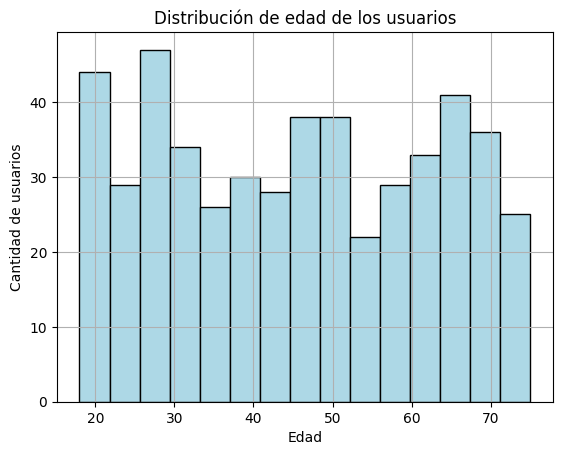

In [12]:
#Creamos grafica de barras para ver la distibucion de edad de los usuarios
users['age'].hist(bins=15, color='lightblue', edgecolor='black')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad de los usuarios')
plt.show()

## Llamadas

In [13]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
print(calls.info())
display(calls.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


,user_id,duration
count,137735.000000,137735.000000
mean,1247.658046,6.745927
std,139.416268,5.839241
min,1000.000000,0.000000
25%,1128.000000,1.290000
50%,1247.000000,5.980000
75%,1365.000000,10.690000
max,1499.000000,37.600000


In [14]:
# Imprime una muestra de datos para las llamadas
display(calls.head(10))

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40



***Al imprimir la información general de las llamadas***

Podemor ver que existen 4 columnas con 137,735 registros de los cuales no existen valores nulos

call_date: Fecha de la llamada es de tipo object (debería ser datetime)

### Corregir los datos

call_date, esta almanecado como object, se cambiar a datetime

In [15]:
# Convertir 'call_date' a tipo datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])

#Revisar cambios
print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


### Enriquecer los datos

Para enriquecer los datos verificaremos cuantas llamadas con 0 minutos de duración hay y decidir si eliminamos los registros o se mantienen.

Confirmar si hay registros duplicados y eliminar los registros.

Generar gráfica para observar la duracion de las llamadas

In [16]:
# Contar total de llamadas antes de filtrar
total_llamadas = calls.shape[0]
print(f'Total de llamadas en el DataFrame: {total_llamadas} \n')
print(calls.info())

Total de llamadas en el DataFrame: 137735 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


In [17]:
# Verificar cuántas llamadas tienen una duración de 0 minutos 
zero_duration_calls = calls[calls['duration'] == 0].shape[0]

if zero_duration_calls > 0:
    print(f'Hay {zero_duration_calls} llamadas con duración 0 minutos.\n')
    
    # Mostrar las llamadas con duración = 0
    print('Estas son las llamadas con duración 0 minutos:')
    display(calls[calls['duration'] == 0])

else:
    print('No hay llamadas con duración 0 minutos.')

Hay 26834 llamadas con duración 0 minutos.

Estas son las llamadas con duración 0 minutos:


,id,user_id,call_date,duration
19,1001_4,1001,2018-12-05,0.0
25,1001_13,1001,2018-12-24,0.0
31,1001_30,1001,2018-10-17,0.0
32,1001_31,1001,2018-11-03,0.0
34,1001_35,1001,2018-12-21,0.0
...,...,...,...,...
137714,1499_183,1499,2018-11-10,0.0
137715,1499_184,1499,2018-09-15,0.0
137720,1499_189,1499,2018-12-27,0.0
137722,1499_191,1499,2018-12-24,0.0


In [18]:
# Filtrar llamadas con duración mayor a 0 minutos 
calls = calls[calls['duration'] > 0]
    
# Mostrar solo la cantidad de llamadas que quedan
print('\nCantidad de llamadas después de filtrar las de duración 0 min:', calls.shape[0])
print('\n')
print(calls.info())



Cantidad de llamadas después de filtrar las de duración 0 min: 110901


<class 'pandas.core.frame.DataFrame'>
Int64Index: 110901 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         110901 non-null  object        
 1   user_id    110901 non-null  int64         
 2   call_date  110901 non-null  datetime64[ns]
 3   duration   110901 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


In [19]:
# Verificar si hay duplicados
duplicates = calls.duplicated().sum()
print(f"Cantidad de registros duplicados: {duplicates}\n")

# Opcional: Eliminar duplicados si existen
if duplicates > 0:
    calls = calls.drop_duplicates()
    print('\nRegistros despues de eliminar duplicados', calls)

# Revisar cambios
print('\n')
print(calls.info())

Cantidad de registros duplicados: 0



<class 'pandas.core.frame.DataFrame'>
Int64Index: 110901 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         110901 non-null  object        
 1   user_id    110901 non-null  int64         
 2   call_date  110901 non-null  datetime64[ns]
 3   duration   110901 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


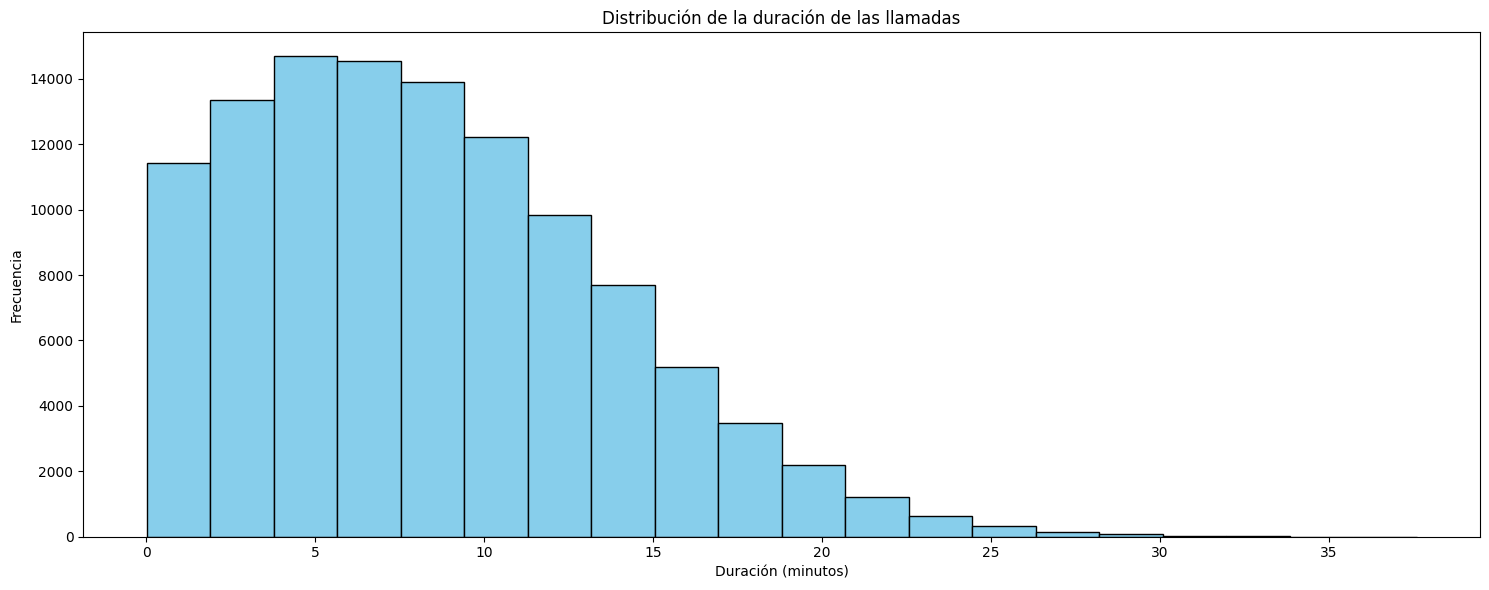

In [20]:
# Este gráfico te permitirá ver cómo se distribuyen las duraciones de las llamadas
plt.figure(figsize=(15, 6))
plt.hist(calls['duration'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de la duración de las llamadas')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [21]:
# Relacion de tiempo de llamadas por Usuarios

# Crear una nueva columna con el valor original de la duración de la llamada
calls['original_duration'] = calls['duration']

# Crear una nueva columna con la duración a facturar (Redondeado hacia arriba)
calls['bill_duration'] = np.ceil(calls['duration'])

# Agrupar por usuario para obtener la suma de la duración original y la duración facturada
user_duration = calls.groupby('user_id').agg({'original_duration': 'sum', 'bill_duration': 'sum'}).reset_index()

# Mostrar resultados
print("Duración real y facturada de llamadas por usuario:")
display(user_duration.head(15))


#Notas codigo np.ceil() --> Redondea hacia arriba; 
#np.floor()             --> Redondea hacia abajo; 
#round() / np.round()   --> Redondea al entero más cercano CUIDADO: puede redondear hacia abajo si es mas cercano el entero más cercano

Duración real y facturada de llamadas por usuario:


,user_id,original_duration,bill_duration
0,1000,116.83,124.0
1,1001,1640.46,1728.0
2,1002,777.13,829.0
3,1003,1041.00,1104.0
4,1004,2618.95,2772.0
5,1005,470.22,496.0
6,1006,64.11,69.0
7,1007,2484.15,2641.0
8,1008,1473.31,1556.0
9,1009,5589.68,5954.0


## Mensajes

In [22]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print(messages.info())
display(messages.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


,user_id
count,76051.000000
mean,1245.972768
std,139.843635
min,1000.000000
25%,1123.000000
50%,1251.000000
75%,1362.000000
max,1497.000000


In [23]:
# Imprime una muestra de datos para los mensajes
display(messages.head(15))

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
5,1000_346,1000,2018-12-29
6,1000_386,1000,2018-12-30
7,1000_413,1000,2018-12-31
8,1000_502,1000,2018-12-27
9,1000_525,1000,2018-12-28


***Al imprimir la información general de los mensajes ***

Podemos observar que tiene 3 columnas con un 76,051  registros de los cuales no hay valores nulos.

message_date: fecha del SMS es de tipo object (debe de ser de tipo datatime)

### Corregir los datos

Se debe cambiar el tipo de dato de la columna message_date a tipo datatime

In [24]:
# Convertir 'message_date' a tipo datetime
messages['message_date'] = pd.to_datetime(messages['message_date'])

#Revisar cambios
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None


### Enriquecer los datos

Verificar si exiten registros duplicados

Generar grafica para observar la distribucion de mensajes enviados agrupados por la fecha.

In [25]:
# Verificar si hay duplicados
duplicates = messages.duplicated().sum()
print(f"Cantidad de registros duplicados: {duplicates}\n")

# Opcional: Eliminar duplicados si existen
if duplicates > 0:
    messages = messages.drop_duplicates()
    print('\nRegistros despues de eliminar duplicados', messages)

# Revisar cambios
print(messages.info())

Cantidad de registros duplicados: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None


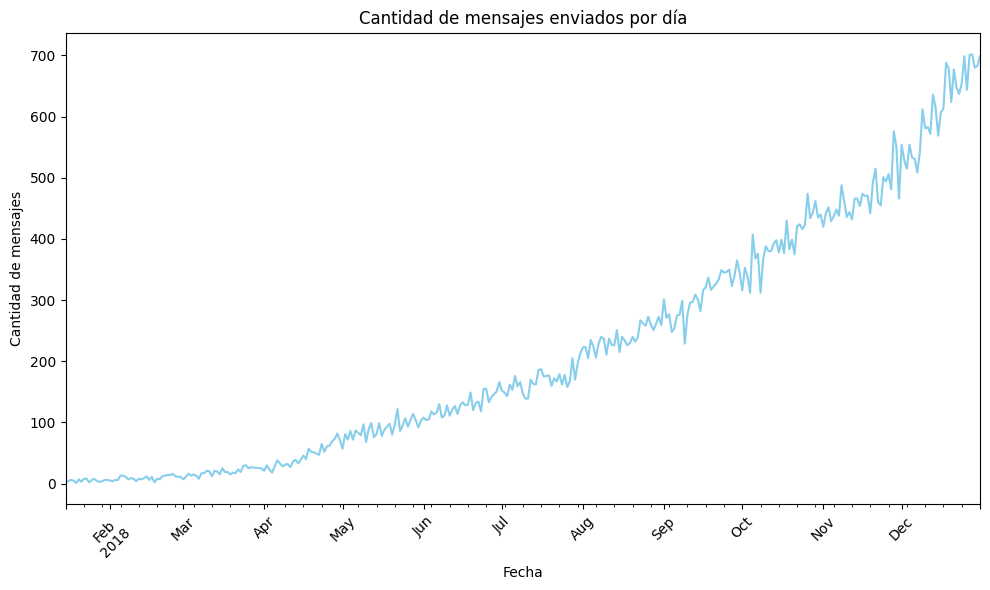

In [26]:
#Este gráfico muestra cómo la cantidad de mensajes enviados varía a lo largo de las fechas.

# Agrupar por fecha y contar los mensajes enviados por día
daily_messages = messages.groupby('message_date')['id'].count()

# Graficar
plt.figure(figsize=(10, 6))
daily_messages.plot(kind='line', color='skyblue')
plt.title('Cantidad de mensajes enviados por día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de mensajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Internet

In [27]:
# Imprime la información general/resumida sobre el DataFrame de internet
print(internet.info())
display(internet.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


,user_id,mb_used
count,104825.000000,104825.000000
mean,1242.496361,366.713701
std,142.053913,277.170542
min,1000.000000,0.000000
25%,1122.000000,136.080000
50%,1236.000000,343.980000
75%,1367.000000,554.610000
max,1499.000000,1693.470000


In [28]:
# Imprime una muestra de datos para el tráfico de internet
display(internet.head(15))

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
5,1001_0,1001,2018-08-24,284.68
6,1001_3,1001,2018-12-09,656.04
7,1001_4,1001,2018-11-04,16.97
8,1001_10,1001,2018-11-27,135.18
9,1001_15,1001,2018-12-13,761.92


***Al imprimir la informacion general de df de internet***

Podemos ver que contiene 4 columnas con 104,825 registros y sin valores nulos

session_date: fecha de la sesión web es de tipo object (debe de ser de tipo data time)

Asi como se puede ver que el minimo de MB usados es 0 y un maximo de 1693.47 MB (Se deben convertir los MB a GB para cálculos)

### Corregir los datos

Convertir session_date a tipo de dato datetime

In [29]:
# Convertir 'session_date' a tipo datetime
internet['session_date'] = pd.to_datetime(internet['session_date'])

# Revisar los cambios
print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


In [30]:
# Verificar si hay duplicados
duplicates = internet.duplicated().sum()
print(f"Cantidad de registros duplicados: {duplicates}\n")

# Opcional: Eliminar duplicados si existen
if duplicates > 0:
    internet = internet.drop_duplicates()
    print('\nRegistros despues de eliminar duplicados', internet)

# Revisar cambios
print(internet.info())


Cantidad de registros duplicados: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


### Enriquecer los datos

Validar si hay registros duplicados

Filtrar registros 0 MB (Verificar que no sean de cuentas canceladas)

Agregar una columna que clasifique las sesiones como de bajo, medio o alto consumo

In [31]:
# Contar total de sesiones
total_sesiones = internet.shape[0]
print(f"Total de sesiones: {total_sesiones}\n")

# Contar sesiones con 0 MB
sesiones_0mb = internet[internet['mb_used'] == 0]

# Muestra cuántas sesiones hay con 0 MB
print(f"Cantidad de sesiones con 0 MB: {len(sesiones_0mb)}\n")

# Filtrar: eliminar sesiones con 0 MB
internet = internet[internet['mb_used'] > 0]

# Confirmar cambio
print(f"Cantidad de sesiones después de filtrar las de 0 MB: {internet.shape[0]}\n")


Total de sesiones: 104825

Cantidad de sesiones con 0 MB: 13747

Cantidad de sesiones después de filtrar las de 0 MB: 91078



In [32]:
# Función para clasificar el consumo de MB bajo, medio o alto
def clasificar_consumo(mb):
    if mb < 300:
        return 'bajo'
    elif mb <= 700:
        return 'medio'
    else:
        return 'alto'

# agregar columna de consumo al DAtaframe
internet['nivel_consumo'] = internet['mb_used'].apply(clasificar_consumo)

# Verificar resultados
display(internet.head(15))

,id,user_id,session_date,mb_used,nivel_consumo
0,1000_13,1000,2018-12-29,89.86,bajo
2,1000_379,1000,2018-12-28,660.40,medio
3,1000_413,1000,2018-12-26,270.99,bajo
4,1000_442,1000,2018-12-27,880.22,alto
5,1001_0,1001,2018-08-24,284.68,bajo
6,1001_3,1001,2018-12-09,656.04,medio
7,1001_4,1001,2018-11-04,16.97,bajo
8,1001_10,1001,2018-11-27,135.18,bajo
9,1001_15,1001,2018-12-13,761.92,alto
10,1001_16,1001,2018-10-28,501.53,medio


## Estudiar las condiciones de las tarifas

In [33]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
display(plans.head())

,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_extra_gb,usd_per_extra_sms,usd_per_extra_min,plan_name,usd_per_min_included,usd_per_sms_included,usd_per_gb_included
0,50,15360,500,20,10,0.03,0.03,surf,0.040000,0.40,1.333333
1,1000,30720,3000,70,7,0.01,0.01,ultimate,0.023333,0.07,2.333333


## Agregar datos por usuario

In [34]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

#nueva columna para el año y mes
calls['period'] = calls['call_date'].dt.to_period('M')

# Agrupa usuario y período, y contar las llamadas
calls_month = calls.groupby(['user_id', 'period']).agg(calls_count=('id', 'count')).reset_index()

# Muestra el resultado
display(calls_month.head(10))


,user_id,period,calls_count
0,1000,2018-12,16
1,1001,2018-08,22
2,1001,2018-09,38
3,1001,2018-10,47
4,1001,2018-11,49
5,1001,2018-12,46
6,1002,2018-10,8
7,1002,2018-11,48
8,1002,2018-12,38
9,1003,2018-12,118


In [35]:
# Crear una columna con la duración original antes de redondear
calls['original_duration'] = calls['duration']

# Redondear hacia arriba la duración de las llamadas
calls['duration'] = np.ceil(calls['duration'])

# Crear una nueva columna para el año y mes
calls['period'] = calls['call_date'].dt.to_period('M')

# Agrupar por usuario y periodo, y sumar los minutos de las llamadas
minutes_month = calls.groupby(['user_id', 'period']).agg(original_minutes=('original_duration', 'sum'),
                                                         bill_minutes=('duration', 'sum')).reset_index()

# Mostrar resultado
display(minutes_month.head(10))

,user_id,period,original_minutes,bill_minutes
0,1000,2018-12,116.83,124.0
1,1001,2018-08,171.14,182.0
2,1001,2018-09,297.69,315.0
3,1001,2018-10,374.11,393.0
4,1001,2018-11,404.59,426.0
5,1001,2018-12,392.93,412.0
6,1002,2018-10,54.13,59.0
7,1002,2018-11,359.76,386.0
8,1002,2018-12,363.24,384.0
9,1003,2018-12,1041.00,1104.0


In [36]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

#nueva columna para el año y mes
messages['period'] = messages['message_date'].dt.to_period('M')

# Agrupar usuario y periodo, y cuenta los mensajes enviados
messages_month = messages.groupby(['user_id', 'period']).agg(messages_count=('id', 'count')).reset_index()

# Mostrar resultado
display(messages_month.head(10))

,user_id,period,messages_count
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36
5,1001,2018-12,44
6,1002,2018-10,15
7,1002,2018-11,32
8,1002,2018-12,41
9,1003,2018-12,50


In [37]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

#nueva columna para el año y mes
internet['period'] = internet['session_date'].dt.to_period('M')

# Agrupar usuario y periodo, y suma los MB usados
internet_month = internet.groupby(['user_id', 'period']).agg(total_data_used=('mb_used', 'sum')).reset_index()

# Mostrar resultado
display(internet_month.head(10))

,user_id,period,total_data_used
0,1000,2018-12,1901.47
1,1001,2018-08,6919.15
2,1001,2018-09,13314.82
3,1001,2018-10,22330.49
4,1001,2018-11,18504.30
5,1001,2018-12,19369.18
6,1002,2018-10,6552.01
7,1002,2018-11,19345.08
8,1002,2018-12,14396.24
9,1003,2018-12,27044.14


In [38]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

# Fusionamos los DataFrames
merged_data = calls_month.merge(
    minutes_month, on=['user_id', 'period'], how='outer').merge(
    messages_month, on=['user_id', 'period'], how='outer').merge(
    internet_month, on=['user_id', 'period'], how='outer')

# Mostramos el DataFrame final
display(merged_data.head())


,user_id,period,calls_count,original_minutes,bill_minutes,messages_count,total_data_used
0,1000,2018-12,16.0,116.83,124.0,11.0,1901.47
1,1001,2018-08,22.0,171.14,182.0,30.0,6919.15
2,1001,2018-09,38.0,297.69,315.0,44.0,13314.82
3,1001,2018-10,47.0,374.11,393.0,53.0,22330.49
4,1001,2018-11,49.0,404.59,426.0,36.0,18504.30


In [39]:
# Añade la información de la tarifa

merged_plan = merged_data.merge(
    users[['user_id', 'plan']], on='user_id', how='left')

# Merged 'plans' para obtener los detalles de la tarifa
final_plan = merged_plan.merge(
    plans[['plan_name', 'usd_monthly_fee', 'minutes_included', 'messages_included', 
           'mb_per_month_included', 'usd_per_extra_min', 'usd_per_extra_sms', 'usd_per_extra_gb']], 
    left_on='plan', right_on='plan_name', how='left')

# Mostramos el DataFrame final con la información de la tarifa
display(final_plan.head())


,user_id,period,calls_count,original_minutes,bill_minutes,messages_count,total_data_used,plan,plan_name,usd_monthly_fee,minutes_included,messages_included,mb_per_month_included,usd_per_extra_min,usd_per_extra_sms,usd_per_extra_gb
0,1000,2018-12,16.0,116.83,124.0,11.0,1901.47,ultimate,ultimate,70,3000,1000,30720,0.01,0.01,7
1,1001,2018-08,22.0,171.14,182.0,30.0,6919.15,surf,surf,20,500,50,15360,0.03,0.03,10
2,1001,2018-09,38.0,297.69,315.0,44.0,13314.82,surf,surf,20,500,50,15360,0.03,0.03,10
3,1001,2018-10,47.0,374.11,393.0,53.0,22330.49,surf,surf,20,500,50,15360,0.03,0.03,10
4,1001,2018-11,49.0,404.59,426.0,36.0,18504.30,surf,surf,20,500,50,15360,0.03,0.03,10


In [40]:
# Primero calculamos el excedente de minutos, mensajes y datos

# Rellena 0 donde haya NaN en 'total_data_used','calls_count','messages_count',messages_included,'minutes_included' y 'mb_per_month_included'
final_plan['total_data_used'] = final_plan['total_data_used'].fillna(0) 
final_plan['calls_count'] = final_plan['calls_count'].fillna(0)
final_plan['messages_count'] = final_plan['messages_count'].fillna(0)
final_plan['minutes_included'] = final_plan['minutes_included'].fillna(0)
final_plan['mb_per_month_included'] = final_plan['mb_per_month_included'].fillna(0)
final_plan['messages_included'] = final_plan['messages_included'].fillna(0)

# Rellena 0 donde haya NaN en las columna de 'plans', 'usd_monthly_fee','usd_per_extra_min','usd_per_extra_sms','usd_per_extra_gb'
final_plan['usd_monthly_fee'] = final_plan['usd_monthly_fee'].fillna(0)
final_plan['usd_per_extra_min'] = final_plan['usd_per_extra_min'].fillna(0)
final_plan['usd_per_extra_sms'] = final_plan['usd_per_extra_sms'].fillna(0)
final_plan['usd_per_extra_gb'] = final_plan['usd_per_extra_gb'].fillna(0)

# Redondeo hacia arriba
final_plan['calls_count'] = np.ceil(final_plan['calls_count'])
final_plan['messages_count'] = np.ceil(final_plan['messages_count'])
final_plan['total_data_used'] = np.ceil(final_plan['total_data_used'] / 1024)  # Convertimos a GB redondeando hacia arriba

# Calculamos los excedentes para llamadas, mensajes y datos
#NOTA: convertimos a GB para poder calcular correctamente el exeso 
final_plan['calls_exceeded'] = (final_plan['calls_count'] - final_plan['minutes_included']).clip(lower=0)
final_plan['messages_exceeded'] = (final_plan['messages_count'] - final_plan['messages_included']).clip(lower=0)
final_plan['data_exceeded'] = (final_plan['total_data_used'] - (final_plan['mb_per_month_included'] / 1024)).clip(lower=0) # Convertir MB a GB


# Ahora calculamos la tarifa mensual correctamente
final_plan['monthly_revenue'] = (
    final_plan['usd_monthly_fee'] +  # Tarifa mensual fija
    final_plan['calls_exceeded'] * final_plan['usd_per_extra_min'] +  # Ingreso por excedente de minutos
    final_plan['messages_exceeded'] * final_plan['usd_per_extra_sms'] +  # Ingreso por excedente de mensajes
    final_plan['data_exceeded'] * final_plan['usd_per_extra_gb'] ) # Ingreso por excedente de datos (convertido a GB)


# Columna para indicar si excede su plan
final_plan['excedente'] = (
    (final_plan['calls_exceeded'] > 0) |
    (final_plan['messages_exceeded'] > 0) |
    (final_plan['data_exceeded'] > 0))

# Si el valor es True, el usuario se ha excedido, de lo contrario es False
# Mostramos el resultado final
display(final_plan[['user_id', 'period', 'monthly_revenue', 'plan', 'excedente']].head(10))


,user_id,period,monthly_revenue,plan,excedente
0,1000,2018-12,70.00,ultimate,False
1,1001,2018-08,20.00,surf,False
2,1001,2018-09,20.00,surf,False
3,1001,2018-10,90.09,surf,True
4,1001,2018-11,60.00,surf,True
5,1001,2018-12,60.00,surf,True
6,1002,2018-10,20.00,surf,False
7,1002,2018-11,60.00,surf,True
8,1002,2018-12,20.00,surf,False
9,1003,2018-12,140.00,surf,True


## Estudia el comportamiento de usuario

### Llamadas

In [41]:
print(final_plan.columns)

Index(['user_id', 'period', 'calls_count', 'original_minutes', 'bill_minutes',
       'messages_count', 'total_data_used', 'plan', 'plan_name',
       'usd_monthly_fee', 'minutes_included', 'messages_included',
       'mb_per_month_included', 'usd_per_extra_min', 'usd_per_extra_sms',
       'usd_per_extra_gb', 'calls_exceeded', 'messages_exceeded',
       'data_exceeded', 'monthly_revenue', 'excedente'],
      dtype='object')


In [42]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. 

# Agrupar por plan y mes, y calcular la duración promedio de las llamadas
duration_calls = final_plan.groupby(['plan', 'period'])['bill_minutes'].mean().reset_index()

# Mostramos las primeras filas del DataFrame resultante
print(duration_calls.head())

   plan   period  bill_minutes
0  surf  2018-01        203.00
1  surf  2018-02        297.00
2  surf  2018-03        330.00
3  surf  2018-04        351.54
4  surf  2018-05        410.24


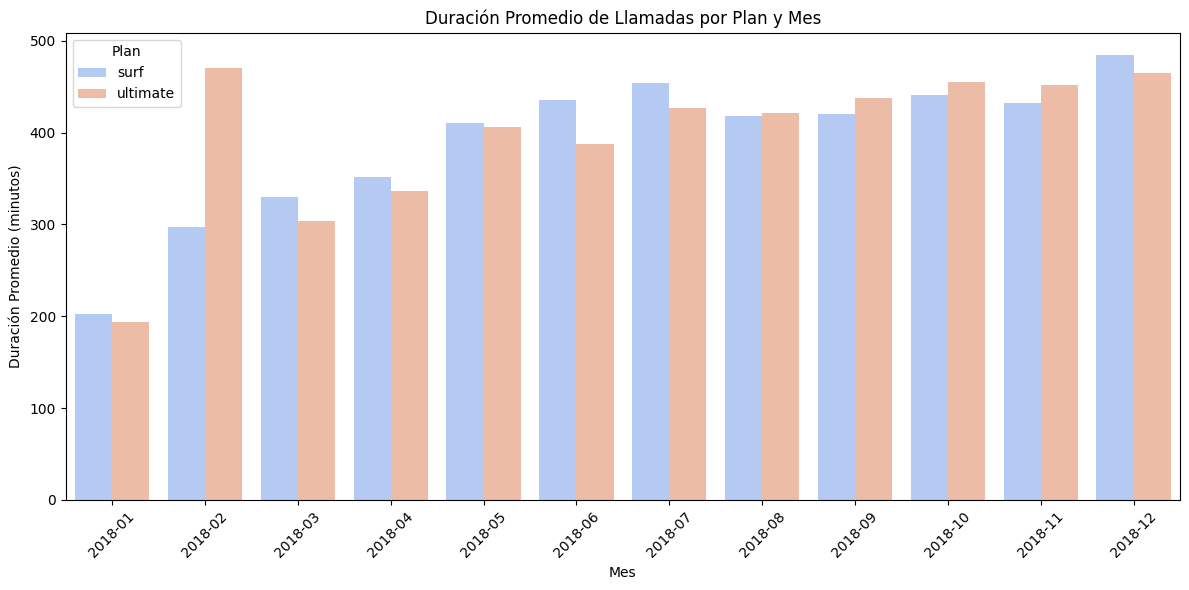

In [43]:
#Traza un gráfico de barras para visualizarla.
# Configuración del gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x='period', y='bill_minutes', hue='plan', data=duration_calls, palette='coolwarm')

# Personalizar el gráfico
plt.title('Duración Promedio de Llamadas por Plan y Mes')
plt.xlabel('Mes')
plt.ylabel('Duración Promedio (minutos)')
plt.xticks(rotation=45)
plt.legend(title='Plan', loc='upper left')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [44]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. 

# Calcular minutos por plan
minute_per_mounth = final_plan.groupby('plan')['bill_minutes'].describe()

# Mostrar las estadísticas
display('Estadistica de uso de minutos mesnsuales de cada plan:', minute_per_mounth)


#visualizar lo que incluyen los planes
display('Que te incluye los planes:', plans)


'Estadistica de uso de minutos mesnsuales de cada plan:'

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1544.0,436.802461,229.088544,2.0,279.0,430.0,579.0,1510.0
ultimate,712.0,435.286517,237.459650,10.0,263.0,425.5,566.0,1369.0


'Que te incluye los planes:'

,messages_included,mb_per_month_included,minutes_included,usd_monthly_fee,usd_per_extra_gb,usd_per_extra_sms,usd_per_extra_min,plan_name,usd_per_min_included,usd_per_sms_included,usd_per_gb_included
0,50,15360,500,20,10,0.03,0.03,surf,0.040000,0.40,1.333333
1,1000,30720,3000,70,7,0.01,0.01,ultimate,0.023333,0.07,2.333333


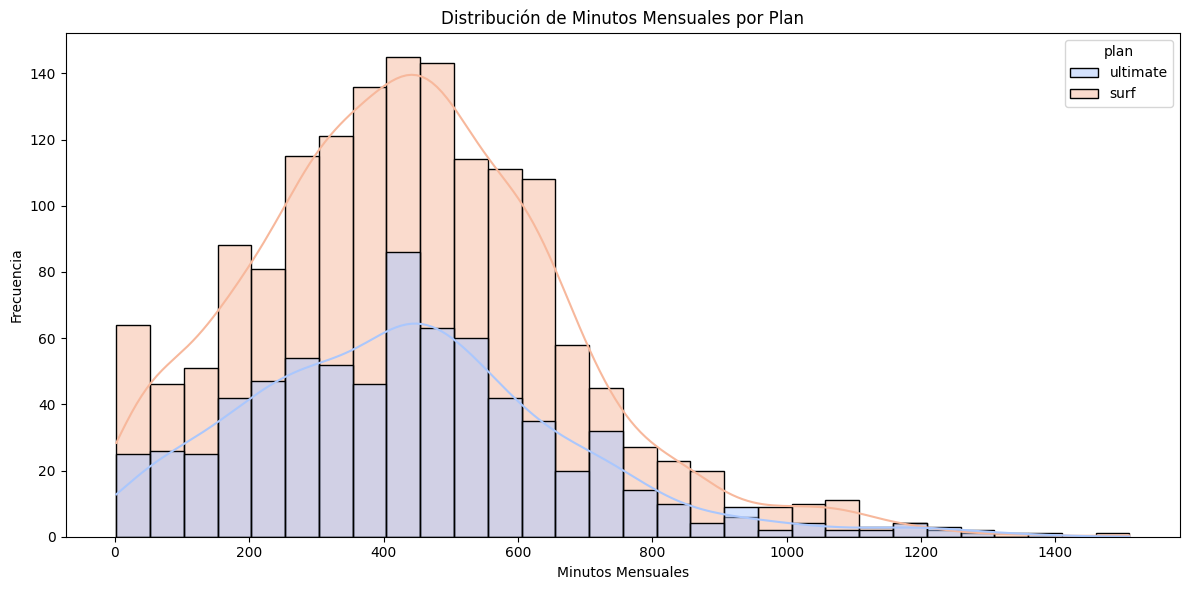

In [45]:
# Traza un histograma.

# Configuración del gráfico
plt.figure(figsize=(12, 6))

# Crear un histograma para comparar los minutos de llamadas por plan
sns.histplot(data=final_plan, x='bill_minutes', hue='plan', kde=True, bins=30, palette='coolwarm')

# Personalización del gráfico
plt.title('Distribución de Minutos Mensuales por Plan')
plt.xlabel('Minutos Mensuales')
plt.ylabel('Frecuencia')


# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [46]:
# Calcula la media y la varianza de la duración mensual de llamadas.

# Calcula la media y la varianza de la duración mensual de llamadas por plan
call_metricas = final_plan.groupby('plan')['bill_minutes'].agg(['mean', 'var']).reset_index()

# Renombrar columnas
call_metricas.columns = ['Plan', 'Media_Minutos', 'Varianza_Minutos']

# Mostrar los resultados
print(call_metricas)


       Plan  Media_Minutos  Varianza_Minutos
0      surf     436.802461      52481.561083
1  ultimate     435.286517      56387.085163


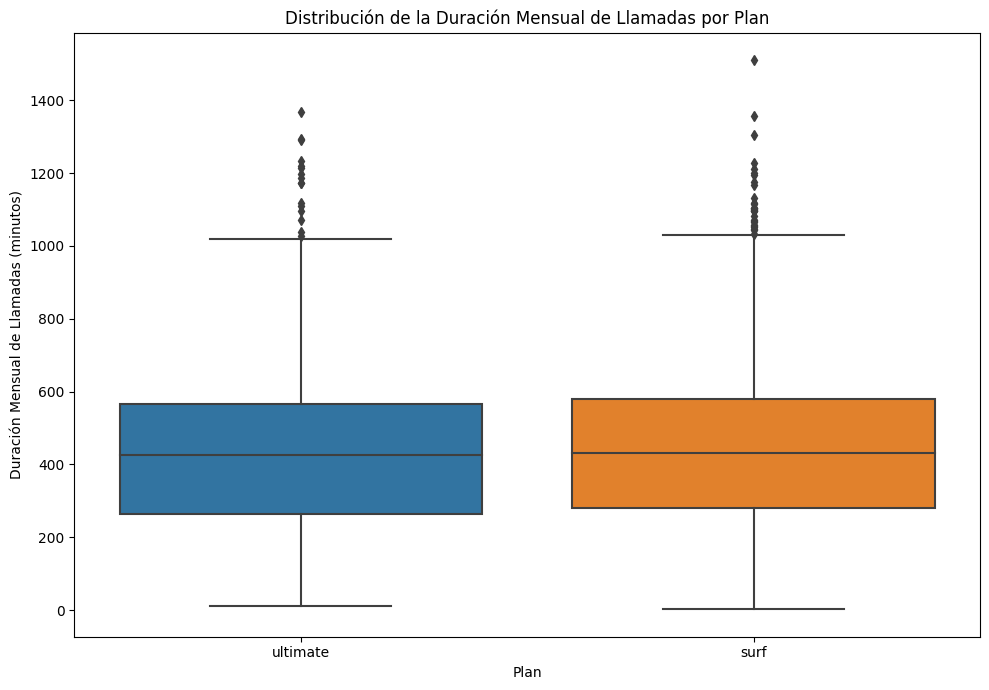

In [47]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

# Configuración del gráfico
plt.figure(figsize=(10, 7))
sns.boxplot(x='plan', y='bill_minutes', data=final_plan)

# Personalizar el gráfico
plt.title('Distribución de la Duración Mensual de Llamadas por Plan')
plt.xlabel('Plan')
plt.ylabel('Duración Mensual de Llamadas (minutos)')

# Mostrar el gráfico
plt.tight_layout()
plt.show()


No hay una diferencia notable en el uso promedio de llamadas mensuales entre ambos planes.

Los usuarios del plan surf usan en promedio 436.80 minutos al mes.
Los del plan ultimate usan 435.28 minutos al mes.
La varianza es ligeramente mayor en el plan "ultimate".

En cuanto a la dispersión, en el plan ultimate los usuarios tienen hábitos de llamada más variados.

### Mensajes

In [48]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

# Agrupar por plan y calcula la media y la varianza de los mensajes enviados al mes
messages_metricas = final_plan.groupby('plan')['messages_count'].agg(['mean', 'var']).reset_index()

# Renombrar columnas
messages_metricas.columns = ['Plan', 'Media_Mensajes', 'Varianza_Mensajes']

# Mostrar resultados
print(messages_metricas)


       Plan  Media_Mensajes  Varianza_Mensajes
0      surf       31.159568        1126.724522
1  ultimate       37.551389        1208.756744


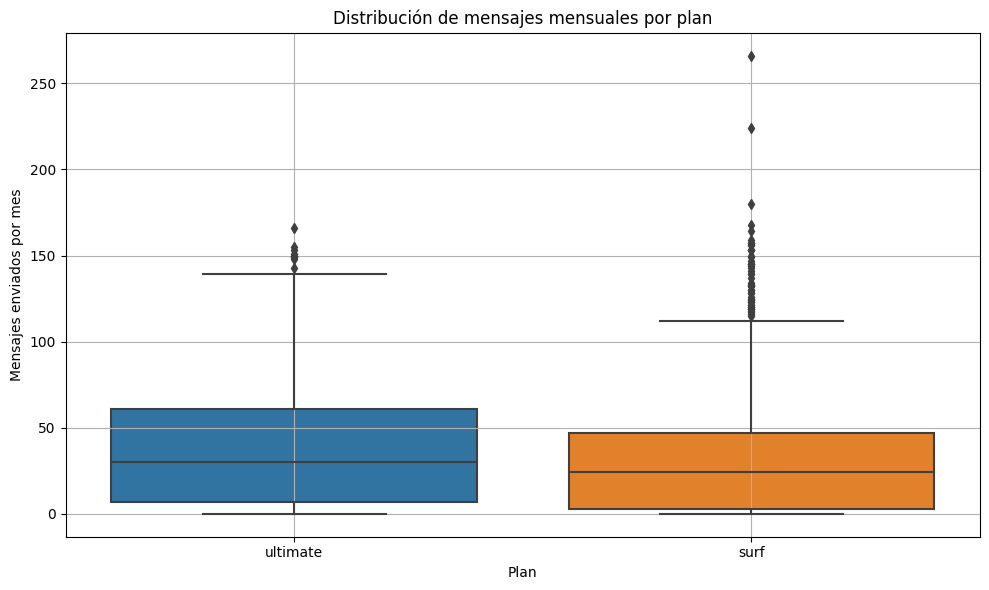

In [49]:
#Diagrama de caja para visualizar la distribución de mensajes que tienden a enviar los usuarios

# Configuración del gráfico
plt.figure(figsize=(10, 6))
sns.boxplot(x='plan', y='messages_count', data=final_plan)

# Personalización
plt.title('Distribución de mensajes mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Mensajes enviados por mes')
plt.grid(True)

# Mostrar gráfico
plt.tight_layout()
plt.show()

Los usuarios del plan Ultimate envían más mensajes al mes (37.6) en comparación con los del plan Surf (31.2). Sugiere que los del plan Ultimate tienden a enviar más mensajes. Ambos planes muestran una varianza similar

Aunque el promedio y la varianza son similares, se puede decir que los usuarios de Ultimate envían más mensajes en promedio. Podria decirse que estan actuando segun los beneficios de su plan.

### Internet

In [50]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

# Agrupar por plan y calcular la media y la varianza del tráfico de Internet usado
internet_metricas = final_plan.groupby('plan')['total_data_used'].agg(['mean', 'var']).reset_index()

# Renombrar columnas
internet_metricas.columns = ['Plan', 'Media_Datos_Internet', 'Varianza_Datos_Internet']

# Mostrar resultados
print(internet_metricas)

       Plan  Media_Datos_Internet  Varianza_Datos_Internet
0      surf             16.670693                 61.58360
1  ultimate             17.306944                 58.83055


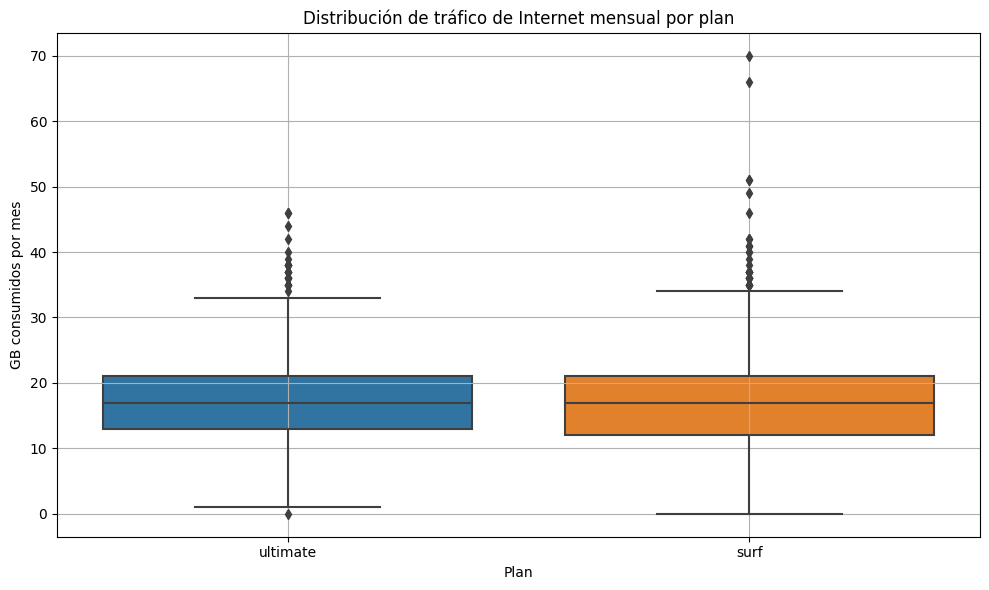

In [51]:
#Diagrama de caja para Compara el tráfico de Internet consumido por usuarios por plan

# Configuración del gráfico
plt.figure(figsize=(10, 6))
sns.boxplot(x='plan', y='total_data_used', data=final_plan)

# Personalización
plt.title('Distribución de tráfico de Internet mensual por plan')
plt.xlabel('Plan')
plt.ylabel('GB consumidos por mes')
plt.grid(True)

# Mostrar gráfico
plt.tight_layout()
plt.show()

Los usuarios del plan Ultimate consumen un poco mas de datos, ya que, en promedio  el plan Ultimate consume 17,215 MB y los usuarios del plan Surf 16,558 MB. Se muestran que la varianza para Surf es ligeramente mayor (64,216,400 frente a 61,652,290).

El comportamiento de consumo de Internet varía ligeramente entre los planes. Los usuarios del plan Ultimate consumen más datos en promedio, pero ambos planes tienen una gran dispersión en el consumo de datos.

## Ingreso

In [52]:
# Calcular los ingresos mensuales para cada usuario
final_plan['monthly_income'] = (
    final_plan['usd_monthly_fee'] +  # Tarifa mensual fija
    final_plan['calls_exceeded'] * final_plan['usd_per_extra_min'] +  # Excedente de minutos
    final_plan['messages_exceeded'] * final_plan['usd_per_extra_sms'] +  # Excedente de mensajes
    final_plan['data_exceeded'] * final_plan['usd_per_extra_gb']  # Excedente de datos
)

# Agrupar por plan y calcular la media y varianza de los ingresos
plan_metricas = final_plan.groupby('plan')['monthly_income'].agg(['mean', 'var']).reset_index()

# Renombrar columnas
plan_metricas.columns = ['Plan', 'Media_Plan', 'Varianza_Plan']

# Mostrar las estadísticas
print(plan_metricas)

       Plan  Media_Plan  Varianza_Plan
0      surf   58.862638    2975.596549
1  ultimate   72.313889     129.848486


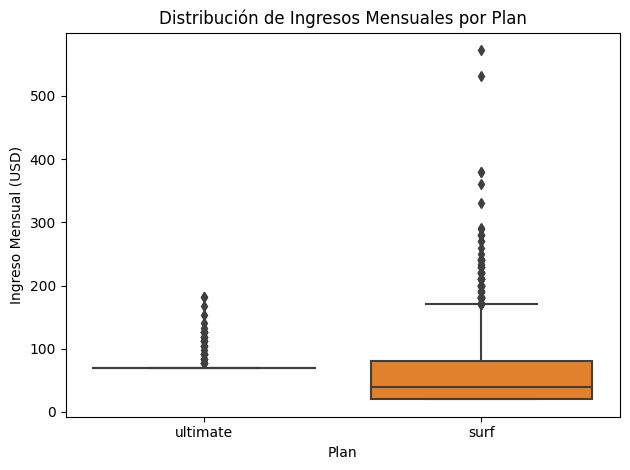

In [53]:
# Crear el boxplot de ingresos mensuales por plan
sns.boxplot(x='plan', y='monthly_income', data=final_plan)

# Personalización
plt.title('Distribución de Ingresos Mensuales por Plan')
plt.xlabel('Plan')
plt.ylabel('Ingreso Mensual (USD)')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

El plan "surf" genera mayor ingreso total promedio que el plan "ultimate.La varianza en los ingresos del plan "surf" es también significativamente mayor. Podria decirse que hay una mayor dependencia de los excedentes en este plan.

El plan "ultimate", aunque tiene un ingreso medio menor, muestra ingresos más estables.
por lo que se puede decir que es porque los usuarios de este plan no tienden a excederse en sus tarifas.

## Prueba las hipótesis estadísticas

Hipótesis nula (H0):Los ingresos promedio de los usuarios de ambos planes son iguales.
 
Hipótesis alternativa (H1):Los ingresos promedio de los usuarios son diferentes entre los dos planes.

Pueba estadística: Prueba t para muestras independientes (dos colas).

Valor alfa: 5% (0.05) de probabilidad de rechazar la hipótesis nula cuando en realidad es verdadera

NOTA DEL RESULTADO SEGUN LA PRUEBA T:

Si valor p < 0.05, se rechaza la hipótesis nula y se concluye que hay una diferencia estadísticamente significativa entre los ingresos promedio de ambos planes.

Si valor p ≥ 0.05, no se rechaza la hipótesis nula, lo que implica que no hay evidencia suficiente para afirmar que los ingresos promedio difieran entre los planes.

In [54]:
# Prueba las hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf

from scipy.stats import ttest_ind

# Filtrar los ingresos de los usuarios según el plan
surf_ingreso = final_plan.loc[final_plan['plan'] == 'surf', 'monthly_income']
ultimate_ingreso = final_plan.loc[final_plan['plan'] == 'ultimate', 'monthly_income']

# Prueba de hipótesis (t-test)
alpha = 0.05  # Nivel de significancia
t_stat, p_value = ttest_ind(surf_ingreso, ultimate_ingreso, equal_var=False) # Usamos equal_var=False en caso de varianzas desiguales

# Resultado
print('Estadístico t:', t_stat)
print('Valor p:', p_value)

if p_value < alpha:
    print("\nRechazamos la hipótesis nula: los ingresos son diferentes.")
else:
    print("\nNo podemos rechazar la hipótesis nula: no hay diferencia significativa.")

Estadístico t: -9.344718611813233
Valor p: 2.5613755181532966e-20

Rechazamos la hipótesis nula: los ingresos son diferentes.


Hipótesis nula (H0):
El ingreso promedio de los usuarios de NY-NJ es igual al ingreso promedio de los usuarios de otras regiones.

Hipótesis alternativa (H1):
El ingreso promedio de los usuarios de NY-NJ es diferente al de los usuarios de otras regiones.

Prueba estadística: Prueba t para muestras independientes (dos colas).

Valor alfa: 5% (0.05) de probabilidad de rechazar la hipótesis nula cuando en realidad es verdadera

In [55]:
# Añadir la ciudad desde el DataFrame users
final_plan = final_plan.merge(users[['user_id', 'city']], on='user_id', how='left')

In [56]:
print(final_plan['city'].unique())

['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Knoxville, TN MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA' 'Pittsburgh, PA MSA'
 'Fresno, CA MSA' 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'Indianapolis-Carmel-Anderson, IN MSA' 'Jacksonville, FL MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'Omaha-Council Bluffs, NE-IA MSA'
 'Houston-The Woodlands-Sugar Land, TX MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Birmingham-Hoover, AL MSA'
 'Oklahoma City, OK MSA' 'Charlotte-Concord-Gastonia, NC-SC MSA'
 'Denver-Aurora-Lakewood, CO MSA'
 'Nashville-Davidson–Murfreesboro–Franklin, TN M

In [57]:
# Prueba las hipótesis 

from scipy.stats import ttest_ind

# Dividimos los datos entre usuarios de NY-NJ y otras regiones
ny_nj_users = final_plan[final_plan['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_revenue']
other_users = final_plan[final_plan['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']['monthly_revenue']

# Prueba t de hipótesis (con varianzas desiguales)
stat, p_value = ttest_ind(ny_nj_users, other_users, equal_var=False)

# Mostramos resultados
print("Estadístico t:", stat)
print("Valor p:", p_value)

# Interpretación del resultado
alpha = 0.05
if p_value < alpha:
    print("\nRechazamos la hipótesis nula: hay una diferencia significativa en los ingresos.")
else:
    print("\nNo se rechaza la hipótesis nula: no hay evidencia de diferencia en los ingresos.")


Estadístico t: -2.1923231649466426
Valor p: 0.028765503550625456

Rechazamos la hipótesis nula: hay una diferencia significativa en los ingresos.


## Conclusión general

Los usuarios del plan surf tienden a superar más fácilmente los límites del plan, lo cual puede traducirse en mayores ingresos para la empresa, aunque a costa de una experiencia posiblemente negativa para el cliente.

El plan ultimate ofrece un uso más estable, con menos cargos adicionales, lo cual puede ser más atractivo para usuarios de alto uso.

Consideraria enviar publicidad para que los usuarios del plan surf se cambien al plan ultimate, para que obtengan una experiencia posiblemente mas positiva al no "pagar extras", ya que son clientes que podrian catalogarse como usuarios de alto uso.